# Setup & Load Data

tweets dataset - https://www.kaggle.com/datasets/kaushiksuresh147/bitcoin-tweets?select=Bitcoin_tweets_dataset_2.csv
sarcasm dataset - https://www.kaggle.com/datasets/danofer/sarcasm/data?select=train-balanced-sarcasm.csv

In [1]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import emoji
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [3]:
btc_df = pd.read_csv(
    "data/Bitcoin_tweets.csv",
    usecols=["date", "text"],   
    dtype={"text": "string"},
    parse_dates=["date"],
    low_memory=True
)
btc_df.head()


In [5]:
btc_df.head()
btc_df = btc_df[['date', 'text']].dropna()

In [12]:
train_sarc = pd.read_csv("data/train-balanced-sarcasm.csv")
train_sarc = train_sarc.rename(columns={"comment": "text"})

train_sarc = train_sarc[['label', 'text']].dropna()

train_sarc.head()


,label,text
0,0,NC and NH.
1,0,You do know west teams play against west teams...
2,0,"They were underdogs earlier today, but since G..."
3,0,"This meme isn't funny none of the ""new york ni..."
4,0,I could use one of those tools.


In [13]:

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    return text

train_sarc['text'] = train_sarc['text'].apply(clean_text)

# Training Sarcasm Model

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_sarc['text'],
    train_sarc['label'],
    test_size=0.2,
    random_state=42,
    stratify=train_sarc['label']
)


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,3),     
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    stop_words=None        
)


X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

'''model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    C=2.0
)'''

from sklearn.svm import LinearSVC

model = LinearSVC()

model.fit(X_train_vec, y_train)


LinearSVC()

In [21]:
from sklearn.metrics import classification_report

pred = model.predict(X_val_vec)
print(classification_report(y_val, pred))


              precision    recall  f1-score   support

           0       0.70      0.76      0.73    101081
           1       0.74      0.68      0.70    101074

    accuracy                           0.72    202155
   macro avg       0.72      0.72      0.72    202155
weighted avg       0.72      0.72      0.72    202155



In [25]:
def sarcasm_probability(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    score = model.decision_function(vec)[0]
    
    # convert decision score to probability using sigmoid
    prob = 1 / (1 + np.exp(-score))
    
    return prob


In [26]:
sample_texts = [
    "Bitcoin is doing AMAZING 😂😂",
    "Yeah right, BTC is totally stable",
    "Bitcoin price rising steadily",
    "BTC crashing hard today"
]

for t in sample_texts:
    print(t)
    print("Sarcasm prob:", sarcasm_probability(t))
    print()


Bitcoin is doing AMAZING 😂😂
Sarcasm prob: 0.5610409618579912

Yeah right, BTC is totally stable
Sarcasm prob: 0.8072775766626097

Bitcoin price rising steadily
Sarcasm prob: 0.5372290416156833

BTC crashing hard today
Sarcasm prob: 0.49669832811799947



In [28]:

analyzer = SentimentIntensityAnalyzer()

def extract_emojis(text):
    return ''.join(c for c in str(text) if c in emoji.EMOJI_DATA)

def remove_emojis(text):
    return ''.join(c for c in str(text) if c not in emoji.EMOJI_DATA)



In [29]:
emoji_sentiment = {
    "😂": 0.6,
    "😭": -0.7,
    "🔥": 0.5,
    "💀": -0.6,
    "🚀": 0.7,
    "😡": -0.8,
    "😍": 0.8
}


In [30]:
def emoji_score(emojis):
    if not emojis:
        return 0
    
    scores = [emoji_sentiment.get(e, 0) for e in emojis]
    
    # repetition intensity boost
    intensity = 1 + 0.1 * (len(emojis) - 1)
    
    return np.mean(scores) * intensity


In [31]:
def baseline_vader(text):
    return analyzer.polarity_scores(str(text))['compound']

def es_vader(text, alpha=0.7, beta=0.3, lambda_sarc=0.8):
    
    text = str(text)
    
    emojis = extract_emojis(text)
    clean_text_only = remove_emojis(text)
    
    s_text = analyzer.polarity_scores(clean_text_only)['compound']
    s_emoji = emoji_score(emojis)
    
    s_base = alpha * s_text + beta * s_emoji
    
    s_prob = sarcasm_probability(text)
    
    # activate sarcasm only when strong
    adjusted_prob = max(0, s_prob - 0.6)
    
    s_final = s_base * (1 - lambda_sarc * adjusted_prob)
    
    return s_final


In [32]:
btc_df = btc_df.sample(n=150_000, random_state=42)

btc_df['vader_score'] = btc_df['text'].apply(baseline_vader)
btc_df['es_score'] = btc_df['text'].apply(es_vader)


In [40]:
btc_df.index = pd.to_datetime(btc_df.index, errors='coerce')
btc_df = btc_df[~btc_df.index.isna()]


In [41]:
print(type(btc_df.index))
print(btc_df.index[:5])
print(btc_df.dtypes)


<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2022-10-12 16:12:45', '2021-07-26 04:45:04',
               '2021-06-20 18:49:56', '2021-08-18 01:30:25',
               '2022-10-12 22:29:10'],
              dtype='datetime64[ns]', name='date', freq=None)
text           string[python]
vader_score           float64
es_score              float64
dtype: object


In [ ]:
one_min_vader = btc_df['vader_score'].resample("1T").mean()
one_min_es = btc_df['es_score'].resample("1T").mean()

five_min_vader = btc_df['vader_score'].resample("5T").mean()
five_min_es = btc_df['es_score'].resample("5T").mean()

fifteen_min_vader = btc_df['vader_score'].resample("15T").mean()
fifteen_min_es = btc_df['es_score'].resample("15T").mean()

one_hour_vader = btc_df['vader_score'].resample("1H").mean()
one_hour_es = btc_df['es_score'].resample("1H").mean()


In [43]:
btc_price = pd.read_csv("data/BTC_price.csv")
btc_price['date'] = pd.to_datetime(btc_price['date'])
btc_price.set_index('date', inplace=True)


FileNotFoundError: [Errno 2] No such file or directory: 'data/BTC_price.csv'

In [44]:
def emoji_vader(text, alpha=0.7, beta=0.3):
    text = str(text)
    emojis = extract_emojis(text)
    clean_text_only = remove_emojis(text)

    s_text = analyzer.polarity_scores(clean_text_only)['compound']
    s_emoji = emoji_score(emojis)

    return alpha * s_text + beta * s_emoji


In [45]:
btc_df['emoji_vader_score'] = btc_df['text'].apply(emoji_vader)


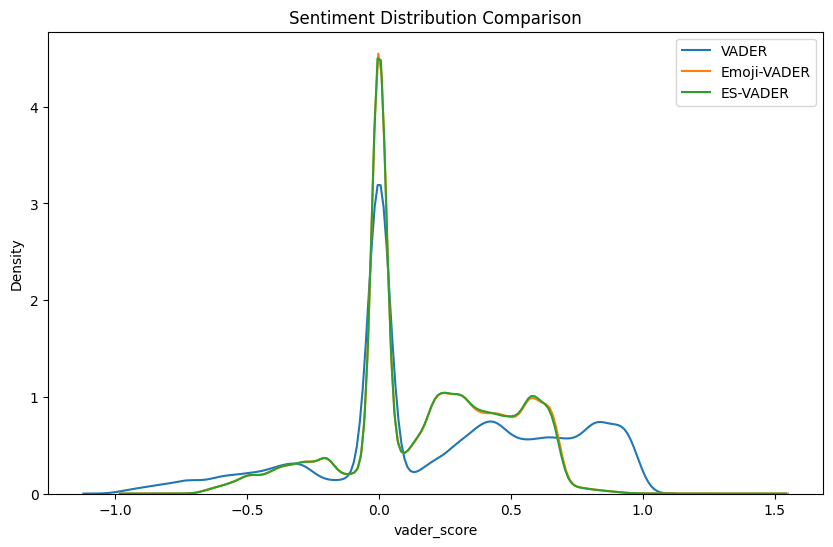

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.kdeplot(btc_df['vader_score'], label='VADER')
sns.kdeplot(btc_df['emoji_vader_score'], label='Emoji-VADER')
sns.kdeplot(btc_df['es_score'], label='ES-VADER')

plt.title("Sentiment Distribution Comparison")
plt.legend()
plt.show()


In [ ]:
btc_df['difference'] = btc_df['es_score'] - btc_df['vader_score']

btc_df.sort_values('difference', ascending=False)[['text','vader_score','es_score']].head(10)


In [ ]:
btc_df.sort_values('difference')[['text','vader_score','es_score']].head(10)


In [47]:
emoji_tweets = btc_df[btc_df['text'].apply(lambda x: len(extract_emojis(x)) > 0)]


In [48]:
print("VADER avg (emoji tweets):", emoji_tweets['vader_score'].mean())
print("Emoji-VADER avg:", emoji_tweets['emoji_vader_score'].mean())
print("ES-VADER avg:", emoji_tweets['es_score'].mean())


VADER avg (emoji tweets): 0.25316312676611685
Emoji-VADER avg: 0.21578406654148688
ES-VADER avg: 0.2149271660076325


In [50]:
btc_df['sarcasm_prob'] = btc_df['text'].apply(sarcasm_probability)


In [51]:
sarcastic = btc_df[btc_df['sarcasm_prob'] > 0.75]

sarcastic[['text','vader_score','es_score','sarcasm_prob']].head(10)


,text,vader_score,es_score,sarcasm_prob
date,,,,
2022-05-25 19:23:00,NEED a #JOB? Sign up now https://t.co/o7lVlsl7...,0.2732,0.163347,0.782318
2022-07-03 23:52:33,Who would have had the highest #bitcoin adopti...,0.0000,0.000000,0.750599
2021-12-30 14:50:08,@alikesici_33 @gauravdahake @thewinkies1 I wil...,0.4019,0.246133,0.756385
2021-07-27 14:16:07,@nf4mation Thanks for giving us such a great o...,0.9571,0.582591,0.763028
2021-08-24 18:33:34,Thanks for giving us such a great opportunity....,0.9571,0.588816,0.751414
2022-04-17 21:10:00,#Hiring? Sign up now https://t.co/o7lVlsl75X F...,0.2732,0.166161,0.763921
2022-06-19 03:07:06,"HEY DEVS, TAKE THIS SURVEY &amp; WIN A MACBOO...",0.6739,0.402953,0.782248
2021-06-22 17:18:01,@adamhoov Because #bitcoin is,0.0000,0.000000,0.760573
2021-07-04 02:19:40,"@Workedia Relax bro, it’s impossible to enforc...",0.4926,0.291863,0.791975


In [52]:
def label_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

btc_df['vader_label'] = btc_df['vader_score'].apply(label_sentiment)
btc_df['es_label'] = btc_df['es_score'].apply(label_sentiment)


In [53]:
pd.crosstab(btc_df['vader_label'], btc_df['es_label'])


es_label,Negative,Neutral,Positive
vader_label,,,
Negative,19759,1147,2654
Neutral,112,44715,3881
Positive,607,2403,74721


In [54]:
from scipy.stats import ttest_rel

ttest_rel(btc_df['vader_score'], btc_df['es_score'])


TtestResult(statistic=108.78651435372882, pvalue=0.0, df=149998)

In [58]:
sample_50 = btc_df.sample(50, )
for i, row in sample_50.iterrows():
    print("="*80)
    print("Tweet:")
    print(row['text'])
    print("\nScores:")
    print(f"VADER       : {row['vader_score']:.4f} ({row['vader_label']})")
    print(f"Emoji-VADER : {row['emoji_vader_score']:.4f}")
    print(f"ES-VADER    : {row['es_score']:.4f} ({row['es_label']})")
    print(f"Sarcasm Prob: {row['sarcasm_prob']:.4f}")


Tweet:
@Cointelegraph $BRISE TO THE MOON 🚀🚀🚀

buy now before it's too late 📈
New ATH 0,0001 🤑🤑🤑

#shiba #Brise #SHIBARMY #BabyDoge #BTC #Binance #Solana #XRP #BriseCommunity #SHIB $SHIB https://t.co/w7yG7QyQvV

Scores:
VADER       : 0.0000 (Neutral)
Emoji-VADER : 0.1440
ES-VADER    : 0.1440 (Positive)
Sarcasm Prob: 0.5331
Tweet:
@cz_binance To all crypto lovers out there 🤗
Check out this new hottie
@pandagirltoken 😎
Get ready for minting events on 04/29 8pm UTC 🤜🤛
@PandaGirlToken  #pandagirl #nft #nftart #giveaway #BTC #ADA #ETH #SHIB #BabyDoge https://t.co/bOwmNz9Rtt https://t.co/4eYaBdN6zE

Scores:
VADER       : 0.8934 (Positive)
Emoji-VADER : 0.4967
ES-VADER    : 0.4967 (Positive)
Sarcasm Prob: 0.5137
Tweet:
Spotted in Miami. Huge @BlockFi ad on I95. Mass adoption in real time. #Bitcoin https://t.co/BWbPOOgR2A

Scores:
VADER       : 0.3182 (Positive)
Emoji-VADER : 0.2227
ES-VADER    : 0.2208 (Positive)
Sarcasm Prob: 0.6108
Tweet:
Earn daily 10%-50% join with me... 100% possible 🖕🖕🖕🖕

In [59]:
emoji_sentiment_auto = {}

for em in emoji.EMOJI_DATA:
    description = emoji.EMOJI_DATA[em]['en']  # English description
    score = analyzer.polarity_scores(description)['compound']
    emoji_sentiment_auto[em] = score

In [60]:
print("🚀:", emoji_sentiment_auto["🚀"])
print("😭:", emoji_sentiment_auto["😭"])
print("💎:", emoji_sentiment_auto["💎"])
print("💀:", emoji_sentiment_auto["💀"])


🚀: 0.0
😭: 0.0
💎: 0.0
💀: 0.0


In [61]:
def emoji_score(emojis):
    if not emojis:
        return 0
    
    scores = [emoji_sentiment_auto.get(e, 0) for e in emojis]
    
    intensity = 1 + 0.1 * (len(emojis) - 1)
    
    return np.mean(scores) * intensity


In [62]:
emoji_sentiment_auto.update({
    "🚀": 0.9,
    "📈": 0.8,
    "📉": -0.8,
    "🐻": -0.7,
    "🐂": 0.7,
    "💎": 0.5
})


In [63]:
btc_df['emoji_vader_score'] = btc_df['text'].apply(emoji_vader)
btc_df['es_score'] = btc_df['text'].apply(es_vader)


In [65]:
for i, row in sample_50.iterrows():
    print("="*80)
    print("Tweet:")
    print(row['text'])
    print("\nScores:")
    print(f"VADER       : {row['vader_score']:.4f} ({row['vader_label']})")
    print(f"Emoji-VADER : {row['emoji_vader_score']:.4f}")
    print(f"ES-VADER    : {row['es_score']:.4f} ({row['es_label']})")
    print(f"Sarcasm Prob: {row['sarcasm_prob']:.4f}")

Tweet:
@Cointelegraph $BRISE TO THE MOON 🚀🚀🚀

buy now before it's too late 📈
New ATH 0,0001 🤑🤑🤑

#shiba #Brise #SHIBARMY #BabyDoge #BTC #Binance #Solana #XRP #BriseCommunity #SHIB $SHIB https://t.co/w7yG7QyQvV

Scores:
VADER       : 0.0000 (Neutral)
Emoji-VADER : 0.1440
ES-VADER    : 0.1440 (Positive)
Sarcasm Prob: 0.5331
Tweet:
@cz_binance To all crypto lovers out there 🤗
Check out this new hottie
@pandagirltoken 😎
Get ready for minting events on 04/29 8pm UTC 🤜🤛
@PandaGirlToken  #pandagirl #nft #nftart #giveaway #BTC #ADA #ETH #SHIB #BabyDoge https://t.co/bOwmNz9Rtt https://t.co/4eYaBdN6zE

Scores:
VADER       : 0.8934 (Positive)
Emoji-VADER : 0.4967
ES-VADER    : 0.4967 (Positive)
Sarcasm Prob: 0.5137
Tweet:
Spotted in Miami. Huge @BlockFi ad on I95. Mass adoption in real time. #Bitcoin https://t.co/BWbPOOgR2A

Scores:
VADER       : 0.3182 (Positive)
Emoji-VADER : 0.2227
ES-VADER    : 0.2208 (Positive)
Sarcasm Prob: 0.6108
Tweet:
Earn daily 10%-50% join with me... 100% possible 🖕🖕🖕🖕

In [66]:
def extract_emojis(text):
    return [c for c in str(text) if c in emoji.EMOJI_DATA]

all_emojis = []

for text in btc_df['text']:
    all_emojis.extend(extract_emojis(text))

unique_emojis = sorted(set(all_emojis))

print(f"Total unique emojis found: {len(unique_emojis)}")
print(unique_emojis)

Total unique emojis found: 1114
['©', '®', '‼', '⁉', '™', 'ℹ', '↔', '↖', '↗', '↘', '↙', '↩', '↪', '⌚', '⌛', '⏏', '⏩', '⏪', '⏫', '⏬', '⏭', '⏰', '⏱', '⏲', '⏳', 'Ⓜ', '▪', '▫', '▶', '◀', '◽', '◾', '☀', '☁', '☂', '☃', '☄', '☎', '☑', '☔', '☕', '☘', '☝', '☠', '☢', '☣', '☦', '☪', '☮', '☯', '☸', '☹', '☺', '♀', '♂', '♈', '♉', '♋', '♍', '♎', '♒', '♓', '♟', '♠', '♣', '♥', '♦', '♨', '♻', '♾', '⚒', '⚓', '⚔', '⚕', '⚖', '⚙', '⚛', '⚜', '⚠', '⚡', '⚪', '⚫', '⚰', '⚱', '⚽', '⚾', '⛄', '⛅', '⛈', '⛎', '⛏', '⛑', '⛓', '⛔', '⛩', '⛰', '⛱', '⛳', '⛵', '⛷', '⛹', '⛺', '⛽', '✂', '✅', '✈', '✉', '✊', '✋', '✌', '✍', '✏', '✒', '✔', '✖', '✝', '✨', '✳', '✴', '❄', '❇', '❌', '❎', '❓', '❔', '❕', '❗', '❣', '❤', '➕', '➖', '➡', '⤴', '⤵', '⬅', '⬆', '⬇', '⬛', '⬜', '⭐', '⭕', '〰', '〽', '㊙', '🀄', '🃏', '🅰', '🅱', '🅾', '🅿', '🆎', '🆒', '🆓', '🆔', '🆕', '🆗', '🆘', '🆙', '🆚', '🈴', '🌀', '🌁', '🌂', '🌃', '🌄', '🌅', '🌆', '🌇', '🌈', '🌉', '🌊', '🌋', '🌌', '🌍', '🌎', '🌏', '🌐', '🌑', '🌒', '🌓', '🌔', '🌕', '🌖', '🌗', '🌘', '🌙', '🌚', '🌛', '🌜', '🌝', '🌞', '🌟', '🌠', '🌡

In [67]:
from collections import Counter

emoji_counts = Counter(all_emojis)

# Sort by frequency descending
sorted_emojis = emoji_counts.most_common()

print(f"Total unique emojis: {len(sorted_emojis)}\n")

for em, count in sorted_emojis:
    print(f"{em}  ->  {count}")


Total unique emojis: 1114

🚀  ->  19011
🔥  ->  10593
✅  ->  4184
🚨  ->  3662
💰  ->  3596
💎  ->  3347
👇  ->  3031
⚡  ->  2830
🔻  ->  2824
🔴  ->  2237
📈  ->  2152
🟢  ->  2077
❤  ->  2062
👉  ->  1876
💥  ->  1796
💯  ->  1790
👀  ->  1628
📣  ->  1558
👍  ->  1556
😂  ->  1487
🐳  ->  1465
🤑  ->  1449
📉  ->  1305
⛏  ->  1224
😍  ->  1194
🦍  ->  1166
➡  ->  1141
💪  ->  1110
🏻  ->  1034
🤣  ->  978
🐋  ->  958
🙌  ->  932
🎉  ->  917
🥳  ->  915
😎  ->  858
🙏  ->  844
🤔  ->  828
🤩  ->  799
⬇  ->  797
💸  ->  790
💵  ->  774
🛑  ->  748
💴  ->  724
📢  ->  675
⬆  ->  662
🥷  ->  654
‼  ->  629
⭐  ->  594
🤝  ->  571
👑  ->  554
♂  ->  513
🟩  ->  510
🏼  ->  509
💜  ->  507
👏  ->  480
🎁  ->  457
✨  ->  452
😉  ->  447
💚  ->  427
💕  ->  420
📅  ->  403
▶  ->  398
👌  ->  389
🪙  ->  381
✌  ->  376
🥰  ->  371
👈  ->  370
🎯  ->  367
⚠  ->  357
🐻  ->  356
👋  ->  344
😌  ->  343
♨  ->  343
🗣  ->  325
🔸  ->  317
💫  ->  294
🏝  ->  287
🤯  ->  282
🤷  ->  282
✔  ->  281
😊  ->  279
🏽  ->  279
🐶  ->  277
😁  ->  276
📋  ->  273
⏳  ->  